In [1]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. Updated PC Path mapping
BASE_DIR = ".."
HAND_PATH = os.path.join(BASE_DIR, "data", "gilgit_hand.tif")
STAGES_DIR = os.path.join(BASE_DIR, "data", "stages")

# Create output folder for clean organization
os.makedirs(STAGES_DIR, exist_ok=True)

# 2. Define Flood Stages (in meters)
stages = [2, 5, 8]
flood_arrays = {}

print("Loading HAND matrix and calculating inundation extents...")

with rasterio.open(HAND_PATH) as src:
    hand_array = src.read(1)
    profile = src.profile
    
    # Update spatial profile for our binary output (1 = flooded, NoData = 0)
    profile.update(dtype=rasterio.int16, nodata=0)
    
    for stage in stages:
        # Array Math: Flood cells where HAND is <= stage. 
        # Ignore NaNs (the void space) using np.isnan
        flooded = np.where((hand_array <= stage) & (~np.isnan(hand_array)), 1, 0)
        
        # Store in dictionary for plotting
        flood_arrays[stage] = flooded.astype('int16')
        
        # Save to disk for Phase 4 GIS overlay
        out_path = os.path.join(STAGES_DIR, f"gilgit_flood_{stage}m.tif")
        with rasterio.open(out_path, 'w', **profile) as dst:
            dst.write(flood_arrays[stage], 1)
            
        print(f"Generated {stage}m stage -> Saved to {out_path}")

print("Phase 3 Array processing complete.")

Loading HAND matrix and calculating inundation extents...
Generated 2m stage -> Saved to ..\data\stages\gilgit_flood_2m.tif
Generated 5m stage -> Saved to ..\data\stages\gilgit_flood_5m.tif
Generated 8m stage -> Saved to ..\data\stages\gilgit_flood_8m.tif
Phase 3 Array processing complete.


=== INUNDATION STATISTICS ===
Stage 2m: 151972 pixels flooded (136.77 sq km)
Stage 5m: 197950 pixels flooded (178.16 sq km)
Stage 8m: 242801 pixels flooded (218.52 sq km)


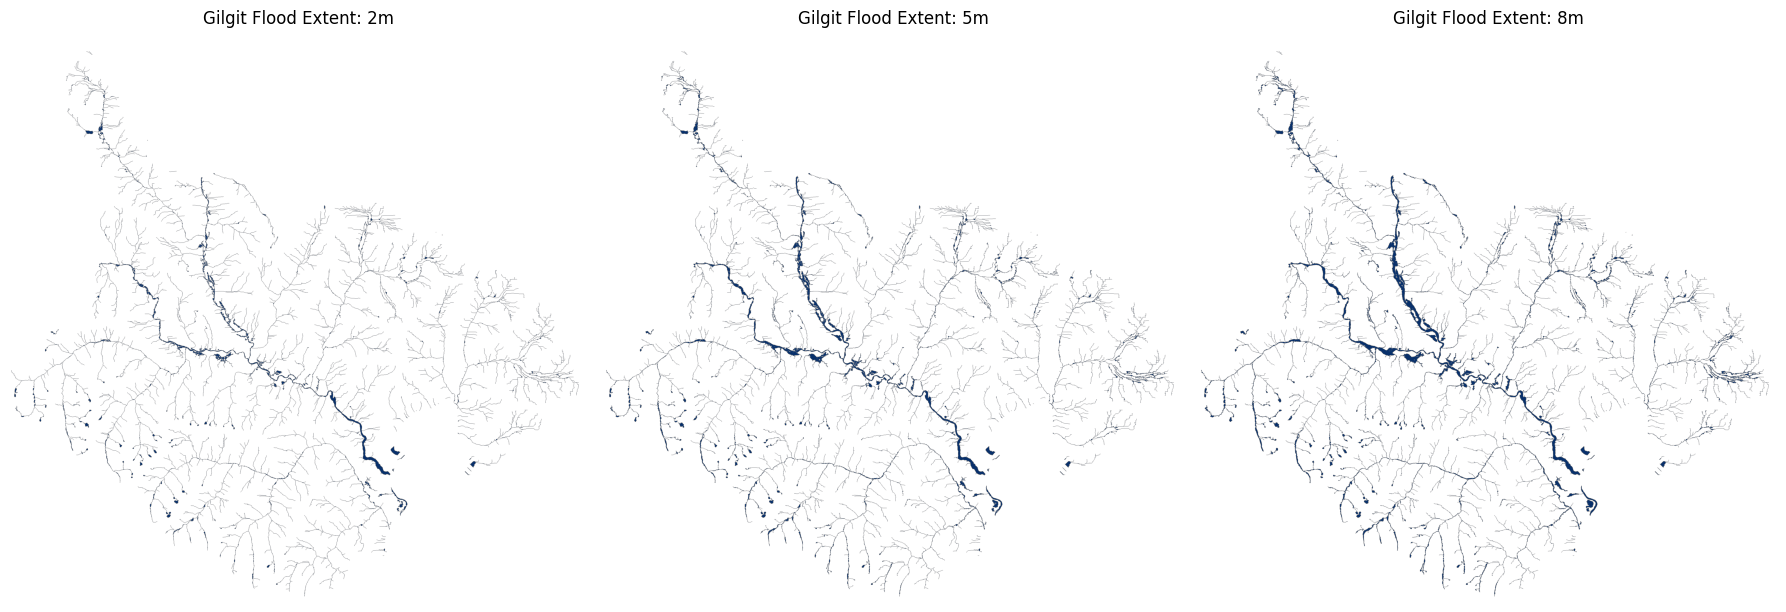

In [2]:
# Inline Visual Verification & Pixel Counting
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

print("=== INUNDATION STATISTICS ===")
for idx, stage in enumerate(stages):
    # 1. Mathematical Proof (Count the 1s)
    pixel_count = np.sum(flood_arrays[stage] == 1)
    
    # 30m x 30m = 900 square meters per pixel. Divide by 1,000,000 for sq km.
    area_sq_km = (pixel_count * 900) / 1_000_000 
    
    print(f"Stage {stage}m: {pixel_count} pixels flooded ({area_sq_km:.2f} sq km)")

    # 2. Visual Fix (Force dark blue using vmin/vmax)
    plot_array = np.where(flood_arrays[stage] == 1, 1, np.nan)
    
    # vmin=0 and vmax=1 forces the colormap to stretch correctly
    ax[idx].imshow(plot_array, cmap="Blues", vmin=0, vmax=1)
    ax[idx].set_title(f"Gilgit Flood Extent: {stage}m")
    ax[idx].axis("off")

plt.tight_layout()
plt.show()